In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Load model and all dependencies
# ─────────────────────────────────────────────────────────────────────────────
import json, os, re, torch, time, gc
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

MODEL_PATH = "/home/lsuryana/.cache/huggingface/hub/Qwen2-VL-7B-Instruct"
print("Loading model...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH, torch_dtype="auto", device_map="cuda")
processor = AutoProcessor.from_pretrained(MODEL_PATH)
print(f"Model loaded. VRAM: {round(torch.cuda.memory_allocated()/1e9,2)} GB")

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46


Loading model...


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Model loaded. VRAM: 16.63 GB


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Load data, prompts, and define all helper functions
# ─────────────────────────────────────────────────────────────────────────────

import json, os, re, torch, time, gc
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from qwen_vl_utils import process_vision_info

# Load preprocessed data
# preprocessed.json contains per sample:
#   frame_dir, trajectory (future t1-t3), past_tokens, past_trajectory, prev_action
with open('results/preprocessed.json') as f:
    data = json.load(f)

# Load 4-step prompt templates
p1 = open('prompts/step1_perception.txt').read()
p2 = open('prompts/step2_prediction.txt').read()
p3 = open('prompts/step3_planning.txt').read()
p4 = open('prompts/step4_behavior.txt').read()

# Maps A-F choice to action name
CHOICE_MAP = {
    'A': 'KEEP_LANE',    'B': 'ACCELERATE',
    'C': 'DECELERATE',   'D': 'CHANGE_LANE_LEFT',
    'E': 'CHANGE_LANE_RIGHT', 'F': 'STOP'
}

IMAGE_SIZE = (320, 180)  # resize from 1600x900 to fit VRAM

# ── Image helpers ─────────────────────────────────────────────────────────────

def resize_image(path):
    """Resize image to 640x360, cache result with _r suffix."""
    tmp = path.replace('.jpg', '_r.jpg')
    if not os.path.exists(tmp):
        img = Image.open(path).convert('RGB').resize(IMAGE_SIZE, Image.LANCZOS)
        img.save(tmp, quality=85)
    return tmp

def get_image_sequence(s, condition):
    """
    Return ordered list of image paths for a sample and condition.

    Non post-hoc: [past frames] + t0
      e.g. [tm3, tm2, tm1, t0]  (4 images if 3 past frames available)

    Post-hoc:     [past frames] + t0 + [future frames]
      e.g. [tm3, tm2, tm1, t0, t1, t2, t3]  (7 images)

    Samples with only 2 past frames get [tm2, tm1, t0] or [tm2, tm1, t0, t1, t2, t3]
    """
    fd = s['frame_dir']
    n_past = s.get('n_past', 0)

    past_frames = []
    if n_past >= 3:
        past_frames = [f"{fd}/tm3.jpg", f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
    elif n_past == 2:
        past_frames = [f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
    elif n_past == 1:
        past_frames = [f"{fd}/tm1.jpg"]

    current = [f"{fd}/t0.jpg"]
    future  = [f"{fd}/t1.jpg", f"{fd}/t2.jpg", f"{fd}/t3.jpg"] \
              if condition == 'posthoc' else []

    return past_frames + current + future

def build_image_description(s, condition):
    """
    Build a text description of the image sequence for the prompt.
    This tells the model what each image represents.
    """
    n_past = s.get('n_past', 0)
    lines = []

    if n_past == 3:
        lines += [
            "- Image 1: t-3 (1.5 seconds before decision point)",
            "- Image 2: t-2 (1.0 second before decision point)",
            "- Image 3: t-1 (0.5 seconds before decision point)",
            "- Image 4: t0  (current frame — DECISION POINT)",
        ]
        if condition == 'posthoc':
            lines += [
                "- Image 5: t+1 (0.5 seconds after decision point)",
                "- Image 6: t+2 (1.0 second after decision point)",
                "- Image 7: t+3 (1.5 seconds after decision point)",
            ]
    elif n_past == 2:
        lines += [
            "- Image 1: t-2 (1.0 second before decision point)",
            "- Image 2: t-1 (0.5 seconds before decision point)",
            "- Image 3: t0  (current frame — DECISION POINT)",
        ]
        if condition == 'posthoc':
            lines += [
                "- Image 4: t+1 (0.5 seconds after decision point)",
                "- Image 5: t+2 (1.0 second after decision point)",
                "- Image 6: t+3 (1.5 seconds after decision point)",
            ]

    return "\n".join(lines)

# ── Inference helpers ─────────────────────────────────────────────────────────

def run_inference(messages):
    """Run single inference call, free VRAM before and after."""
    torch.cuda.empty_cache()
    gc.collect()
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=128, temperature=0.0, do_sample=False)
    trimmed = out[:, inputs['input_ids'].shape[1]:]
    result = processor.decode(trimmed[0], skip_special_tokens=True)
    del inputs, out, trimmed
    torch.cuda.empty_cache()
    return result

def parse_step(raw, step):
    """Extract labelled field from raw model output."""
    patterns = {
        'perception': r'PERCEPTION:\s*(.*?)$',
        'prediction': r'PREDICTION:\s*(.*?)$',
        'planning':   r'PLANNING:\s*(.*?)$',
        'choice':     r'CHOICE:\s*([A-F])',
        'action':     r'ACTION:\s*(\w+)',
        'reasoning':  r'REASONING:\s*(.*?)$',
    }
    match = re.search(patterns[step], raw, re.DOTALL)
    return match.group(1).strip() if match else ''

# ── GT derivation ─────────────────────────────────────────────────────────────

def derive_gt_action(traj):
    """
    Derive GT action from future ego trajectory (t0→t3).
    Heuristic thresholds — documented as Limitation L1.
    """
    x1, x3, y3 = traj[0]['x'], traj[2]['x'], traj[2]['y']
    if abs(x3) < 0.5:   return 'STOP'
    if y3 > 3.0:        return 'CHANGE_LANE_LEFT'
    if y3 < -3.0:       return 'CHANGE_LANE_RIGHT'
    if x1 < 1.5:        return 'DECELERATE'
    if x3 > 12.0:       return 'ACCELERATE'
    return 'KEEP_LANE'

print(f"Loaded {len(data)} samples.")
print("Helper functions ready.")
print("\nSample prev_action distribution:")
from collections import Counter
prev_dist = Counter(s.get('prev_action','UNKNOWN') for s in data)
for k, v in sorted(prev_dist.items(), key=lambda x: -x[1]):
    print(f"  {k:<20} {v}")

Loaded 24 samples.
Helper functions ready.

Sample prev_action distribution:
  WAS_MOVING           9
  WAS_STOPPED          7
  WAS_FAST             7
  WAS_SLOW             1


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2b: run_condition_v2
# Runs all 4 sequential steps for one condition.
# Includes past frames, prev_action context, and image sequence description.
# ─────────────────────────────────────────────────────────────────────────────

def run_condition_v2(s, condition):
    """
    Run 4-step sequential inference for one sample and condition.

    s:         sample dict from preprocessed.json
    condition: 'non_posthoc' or 'posthoc'

    Returns dict with: perception, prediction, planning,
                       action, choice, reasoning, n_images
    """
    images  = get_image_sequence(s, condition)
    resized = [resize_image(img) for img in images]
    n_total = len(images)
    n_past  = s.get('n_past', 0)
    prev_action = s.get('prev_action', 'UNKNOWN')

    # Build image description for prompts
    img_desc = build_image_description(s, condition)

    # Build context header — tells model what it is seeing
    # and what the vehicle was doing before
    if condition == 'posthoc':
        context_header = (
            f"You have access to {n_total} images showing the driving scene:\n"
            f"{img_desc}\n\n"
            f"Vehicle state before decision point: {prev_action}\n"
            f"Ground-truth future trajectory of ego vehicle "
            f"(x=forward meters, y=left meters, relative to t0):\n"
            f"  t+0.5s: x={s['trajectory'][0]['x']}, y={s['trajectory'][0]['y']}\n"
            f"  t+1.0s: x={s['trajectory'][1]['x']}, y={s['trajectory'][1]['y']}\n"
            f"  t+1.5s: x={s['trajectory'][2]['x']}, y={s['trajectory'][2]['y']}\n"
        )
    else:
        context_header = (
            f"You have access to {n_total} images showing the driving scene:\n"
            f"{img_desc}\n\n"
            f"Vehicle state before decision point: {prev_action}\n"
        )

    def img_content():
        return [{"type": "image", "image": p} for p in resized]

    # ── Step 1: Perception — include full context header ──────────────────────
    # context_header tells the model what images it sees and vehicle state
    prompt1 = context_header + "\n" + p1
    msg1 = [{"role": "user", "content":
        img_content() + [{"type": "text", "text": prompt1}]}]
    raw1 = run_inference(msg1)
    ans_perc = parse_step(raw1, 'perception') or raw1.strip()
    
    # ── Step 2: Prediction — no context_header, model already knows from step 1
    prompt2 = p2.replace('{PERCEPTION_ANSWER}', ans_perc)
    msg2 = [{"role": "user", "content":
        img_content() + [{"type": "text", "text": prompt2}]}]
    raw2 = run_inference(msg2)
    ans_pred = parse_step(raw2, 'prediction') or raw2.strip()
    
    # ── Step 3: Planning — no context_header
    prompt3 = p3.replace('{PERCEPTION_ANSWER}', ans_perc)\
                 .replace('{PREDICTION_ANSWER}', ans_pred)
    msg3 = [{"role": "user", "content":
        img_content() + [{"type": "text", "text": prompt3}]}]
    raw3 = run_inference(msg3)
    ans_plan = parse_step(raw3, 'planning') or raw3.strip()
    
    # ── Step 4: Behavior — no context_header
    prompt4 = p4.replace('{PERCEPTION_ANSWER}', ans_perc)\
                 .replace('{PREDICTION_ANSWER}', ans_pred)\
                 .replace('{PLANNING_ANSWER}', ans_plan)
    
    msg4 = [{"role": "user", "content":
        img_content() + [{"type": "text", "text": prompt4}]}]
    raw4 = run_inference(msg4)

    choice    = parse_step(raw4, 'choice')
    action    = CHOICE_MAP.get(choice, 'PARSE_ERROR')
    reasoning = parse_step(raw4, 'reasoning') or raw4.strip()

    return {
        'perception': ans_perc,
        'prediction': ans_pred,
        'planning':   ans_plan,
        'action':     action,
        'choice':     choice,
        'reasoning':  reasoning,
        'n_images':   n_total,
    }

# Verify image sequences for sample 0 and 7
print("Image sequences:")
for idx in [0, 7]:
    s = data[idx]
    non_imgs = get_image_sequence(s, 'non_posthoc')
    post_imgs = get_image_sequence(s, 'posthoc')
    print(f"\nSample {idx} ({s['sample_token'][:8]}):")
    print(f"  prev_action : {s.get('prev_action','UNKNOWN')}")
    print(f"  non_posthoc : {len(non_imgs)} images {[os.path.basename(p) for p in non_imgs]}")
    print(f"  posthoc     : {len(post_imgs)} images {[os.path.basename(p) for p in post_imgs]}")

Image sequences:

Sample 0 (6dabc0fb):
  prev_action : WAS_STOPPED
  non_posthoc : 4 images ['tm3.jpg', 'tm2.jpg', 'tm1.jpg', 't0.jpg']
  posthoc     : 7 images ['tm3.jpg', 'tm2.jpg', 'tm1.jpg', 't0.jpg', 't1.jpg', 't2.jpg', 't3.jpg']

Sample 7 (c5f58c19):
  prev_action : WAS_MOVING
  non_posthoc : 3 images ['tm2.jpg', 'tm1.jpg', 't0.jpg']
  posthoc     : 6 images ['tm2.jpg', 'tm1.jpg', 't0.jpg', 't1.jpg', 't2.jpg', 't3.jpg']



Sample 1: 6dabc0fb1df0...
GT action  : STOP
Prev action: WAS_STOPPED
Trajectory : [{'x': -0.0, 'y': -0.0}, {'x': 0.0, 'y': -0.0}, {'x': -0.0, 'y': -0.0}]


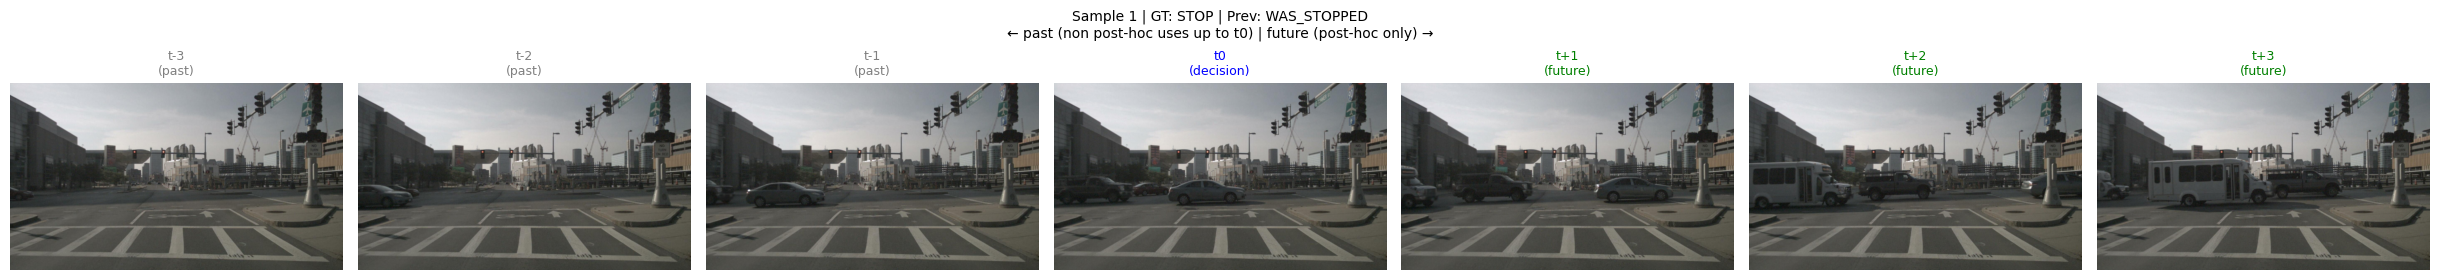


NON POST-HOC: 4 images (3 past + 1 current)


/home/lsuryana/miniconda3/envs/rq2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/lsuryana/miniconda3/envs/rq2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/lsuryana/miniconda3/envs/rq2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Done in 25.3s → ACTION: STOP

POST-HOC: 7 images (3 past + 1 current + 3 future)


KeyboardInterrupt: 

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Smoke test — 4-step inference on 2 samples
# Sample 0: stationary scene (GT=STOP, prev=WAS_STOPPED)
# Sample 7: moving scene     (GT=ACCELERATE, prev=WAS_MOVING)
# Saves to results/smoke_test_v2_outputs.json
# ─────────────────────────────────────────────────────────────────────────────

smoke_results = []

for SAMPLE_IDX in [0, 7]:
    s   = data[SAMPLE_IDX]
    fd  = s['frame_dir']
    gt  = derive_gt_action(s['trajectory'])
    prev = s.get('prev_action', 'UNKNOWN')
    n_past = s.get('n_past', 0)

    print(f"\n{'='*60}")
    print(f"Sample {SAMPLE_IDX+1}: {s['sample_token'][:12]}...")
    print(f"GT action  : {gt}")
    print(f"Prev action: {prev}")
    print(f"Trajectory : {s['trajectory']}")

    # ── Show all frames (past + current + future) ─────────────────────────────
    all_labels = []
    all_paths  = []
    for i in range(n_past, 0, -1):
        label = f"tm{i}"
        path  = f"{fd}/{label}.jpg"
        if os.path.exists(path):
            all_labels.append(f"t-{i}\n({'past'})")
            all_paths.append(path)
    all_labels.append("t0\n(decision)")
    all_paths.append(f"{fd}/t0.jpg")
    for i in range(1, 4):
        all_labels.append(f"t+{i}\n(future)")
        all_paths.append(f"{fd}/t{i}.jpg")

    n_show = len(all_paths)
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 3.5, 3))
    for ax, path, label in zip(axes, all_paths, all_labels):
        ax.imshow(Image.open(path))
        color = 'blue' if 't0' in label else ('green' if 'future' in label else 'gray')
        ax.set_title(label, fontsize=9, color=color)
        ax.axis('off')
    plt.suptitle(
        f"Sample {SAMPLE_IDX+1} | GT: {gt} | Prev: {prev}\n"
        f"← past (non post-hoc uses up to t0) | future (post-hoc only) →",
        fontsize=10)
    plt.tight_layout()
    plt.show()

    # ── Run non post-hoc ──────────────────────────────────────────────────────
    non_imgs = get_image_sequence(s, 'non_posthoc')
    print(f"\nNON POST-HOC: {len(non_imgs)} images ({n_past} past + 1 current)")
    t0 = time.time()
    out_non = run_condition_v2(s, 'non_posthoc')
    print(f"Done in {time.time()-t0:.1f}s → ACTION: {out_non['action']}")

    # ── Run post-hoc ──────────────────────────────────────────────────────────
    post_imgs = get_image_sequence(s, 'posthoc')
    print(f"\nPOST-HOC: {len(post_imgs)} images ({n_past} past + 1 current + 3 future)")
    t0 = time.time()
    out_post = run_condition_v2(s, 'posthoc')
    print(f"Done in {time.time()-t0:.1f}s → ACTION: {out_post['action']}")

    # ── Save ──────────────────────────────────────────────────────────────────
    smoke_results.append({
        'sample_idx':    SAMPLE_IDX,
        'sample_token':  s['sample_token'],
        'gt_action':     gt,
        'prev_action':   prev,
        'trajectory':    s['trajectory'],
        'past_trajectory': s.get('past_trajectory', []),
        'non_posthoc':   out_non,
        'posthoc':       out_post,
    })
    with open('results/smoke_test_v2_outputs.json', 'w') as f:
        json.dump(smoke_results, f, indent=2)
    print("Saved checkpoint.")

    # ── Display comparison table ──────────────────────────────────────────────
    action_changed = out_non['action'] != out_post['action']
    display(HTML(f"""
    <table style="width:100%; border-collapse:collapse; font-size:12px; font-family:monospace;">
    <tr style="background:#e8f0fe;">
        <th style="padding:8px; border:1px solid #ccc; width:12%;">Step</th>
        <th style="padding:8px; border:1px solid #ccc; width:44%;">
            NON POST-HOC ({len(non_imgs)} images: past+t0)</th>
        <th style="padding:8px; border:1px solid #ccc; width:44%;">
            POST-HOC ({len(post_imgs)} images: past+t0+future)</th>
    </tr>
    <tr>
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold; background:#f5f5f5;">
            Perception</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">
            {out_non['perception'][:400]}</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">
            {out_post['perception'][:400]}</td>
    </tr>
    <tr>
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold; background:#f5f5f5;">
            Prediction</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">
            {out_non['prediction'][:400]}</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">
            {out_post['prediction'][:400]}</td>
    </tr>
    <tr>
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold; background:#f5f5f5;">
            Planning</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">
            {out_non['planning'][:400]}</td>
        <td style="padding:8px; border:1px solid #ccc; vertical-align:top;">
            {out_post['planning'][:400]}</td>
    </tr>
    <tr style="background:#fff9e6;">
        <td style="padding:8px; border:1px solid #ccc; font-weight:bold; background:#f5f5f5;">
            Action</td>
        <td style="padding:8px; border:1px solid #ccc; text-align:center;">
            <b style="font-size:15px; color:{'green' if out_non['action']==gt else 'red'};">
            {out_non['action']}</b><br>
            <small style="color:#666;">{out_non['reasoning'][:200]}</small>
        </td>
        <td style="padding:8px; border:1px solid #ccc; text-align:center;">
            <b style="font-size:15px; color:{'green' if out_post['action']==gt else 'red'};">
            {out_post['action']}</b><br>
            <small style="color:#666;">{out_post['reasoning'][:200]}</small>
        </td>
    </tr>
    <tr style="background:#f0f0f0;">
        <td colspan="3" style="padding:10px; border:1px solid #ccc; text-align:center;">
            <b>GT ACTION: {gt}</b> &nbsp;|&nbsp;
            <b>PREV ACTION: {prev}</b> &nbsp;|&nbsp;
            <b>Action changed?</b>
            {'<span style="color:orange; font-weight:bold;"> YES ⚠</span>'
             if action_changed else
             '<span style="color:green; font-weight:bold;"> NO ✓</span>'}
        </td>
    </tr>
    </table>
    """))

print(f"\n{'='*60}")
print(f"Smoke test complete. {len(smoke_results)} samples saved.")
print(f"File: results/smoke_test_v2_outputs.json")

In [5]:
# Run in a new cell after interrupting
import torch
print(f"VRAM used: {round(torch.cuda.memory_allocated()/1e9, 2)} GB")
print(f"VRAM reserved: {round(torch.cuda.memory_reserved()/1e9, 2)} GB")

VRAM used: 16.94 GB
VRAM reserved: 32.22 GB


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Full inference — all 24 samples
# Run ONLY after smoke test (Cell 3) looks correct.
# Checkpoints after every sample — safe to interrupt and resume.
# Output: results/inference_outputs_v2.json
# ─────────────────────────────────────────────────────────────────────────────

CHECKPOINT_FILE = 'results/inference_checkpoint_v2.json'
OUTPUT_FILE     = 'results/inference_outputs_v2.json'

# Load checkpoint if exists
done_tokens = set()
results = []
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        results = json.load(f)
    done_tokens = {r['sample_token'] for r in results}
    print(f"Resuming from checkpoint: {len(done_tokens)}/24 done")
else:
    print("Starting fresh run...")

total_start = time.time()

for idx, s in enumerate(data):
    if s['sample_token'] in done_tokens:
        print(f"[{idx+1}/24] Skipping {s['sample_token'][:8]}... (already done)")
        continue

    fd   = s['frame_dir']
    gt   = derive_gt_action(s['trajectory'])
    prev = s.get('prev_action', 'UNKNOWN')
    n_past = s.get('n_past', 0)

    print(f"\n[{idx+1}/24] {s['sample_token'][:8]}... GT={gt} PREV={prev}")

    # Show frames
    n_non  = len(get_image_sequence(s, 'non_posthoc'))
    n_post = len(get_image_sequence(s, 'posthoc'))

    all_paths, all_labels = [], []
    for i in range(n_past, 0, -1):
        path = f"{fd}/tm{i}.jpg"
        if os.path.exists(path):
            all_paths.append(path)
            all_labels.append(f"t-{i}")
    all_paths.append(f"{fd}/t0.jpg");  all_labels.append("t0★")
    for i in range(1, 4):
        all_paths.append(f"{fd}/t{i}.jpg"); all_labels.append(f"t+{i}")

    fig, axes = plt.subplots(1, len(all_paths), figsize=(len(all_paths)*3, 2.5))
    for ax, path, label in zip(axes, all_paths, all_labels):
        ax.imshow(Image.open(path))
        ax.set_title(label, fontsize=8,
                     color='blue' if '★' in label else
                           'green' if '+' in label else 'gray')
        ax.axis('off')
    plt.suptitle(f"[{idx+1}/24] GT:{gt} PREV:{prev}", fontsize=9)
    plt.tight_layout()
    plt.show()

    # Non post-hoc
    print(f"  NON POST-HOC ({n_non} imgs)...", end=' ')
    t0 = time.time()
    out_non = run_condition_v2(s, 'non_posthoc')
    print(f"{time.time()-t0:.1f}s → {out_non['action']}")

    # Post-hoc
    print(f"  POST-HOC ({n_post} imgs)...", end=' ')
    t0 = time.time()
    out_post = run_condition_v2(s, 'posthoc')
    print(f"{time.time()-t0:.1f}s → {out_post['action']}")

    # Save result
    results.append({
        'sample_token':    s['sample_token'],
        'scene_token':     s['scene_token'],
        'gt_action':       gt,
        'prev_action':     prev,
        'trajectory':      s['trajectory'],
        'past_trajectory': s.get('past_trajectory', []),
        'n_past':          n_past,
        'non_posthoc':     out_non,
        'posthoc':         out_post,
    })

    # Checkpoint
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(results, f, indent=2)

    # Inline summary
    changed = out_non['action'] != out_post['action']
    display(HTML(f"""
    <div style="font-family:monospace; font-size:12px; padding:8px;
                border-left:4px solid {'orange' if changed else 'green'};
                margin:4px 0; background:{'#fff8e1' if changed else '#f1f8e9'};">
        <b>[{idx+1}/24]</b> &nbsp;
        NON: <span style="color:{'green' if out_non['action']==gt else 'red'}">
             {out_non['action']}</span> &nbsp;|&nbsp;
        POST: <span style="color:{'green' if out_post['action']==gt else 'red'}">
              {out_post['action']}</span> &nbsp;|&nbsp;
        GT: <b>{gt}</b> &nbsp;|&nbsp;
        PREV: {prev} &nbsp;|&nbsp;
        {'<b style="color:orange;">CHANGED ⚠</b>' if changed
         else '<b style="color:green;">SAME ✓</b>'}
    </div>
    """))

# Final output
with open(OUTPUT_FILE, 'w') as f:
    json.dump(results, f, indent=2)

total_time = time.time() - total_start
n = len(results)
change_rate = sum(1 for r in results
    if r['non_posthoc']['action'] != r['posthoc']['action']) / n
acc_non  = sum(1 for r in results
    if r['non_posthoc']['action'] == r['gt_action']) / n
acc_post = sum(1 for r in results
    if r['posthoc']['action']    == r['gt_action']) / n

print(f"\n{'='*50}")
print(f"DONE — {n} samples in {total_time/60:.1f} minutes")
print(f"Non post-hoc accuracy : {acc_non:.3f}")
print(f"Post-hoc accuracy     : {acc_post:.3f}")
print(f"Change rate           : {change_rate:.3f}")
print(f"Saved to              : {OUTPUT_FILE}")